# 出力制御は天気で説明できるか？ — データ分析チュートリアル

**太陽光の出力制御（カーテイルメント）が、天気・曜日・季節でどこまで説明できるか**を、
九州電力送配電の実際の公開データで検証していくノートブックです。

このノートブックは [experiments/id01_curtailment_compare/](.) の検証をもとにした教材です。
単に「きれいな結果」を見せるのではなく、**仮説を立てる → データを疑う → バグに気づく → モデルを改善する**という、データ分析の実際の進め方を順番に追体験できるように作っています。

## 使い方
- 上から順にセルを実行してください（`Shift+Enter`）。
- 必要なデータは `data/processed/` に同梱済みなので、追加のAPIキーなどは不要です
  （本家のプロジェクトでは九州電力送配電のExcel・農研機構AMGSDS・資源エネルギー庁FITポータル等から
  取得していますが、取得スクリプト自体は `src/fetch_*.py` を参照してください）。
- もっと詳しく知りたい場合は [README.md](README.md)・[REPORT.md](REPORT.md)・
  [CORRECTIONS_LOG.md](CORRECTIONS_LOG.md) を参照してください
  （特にCORRECTIONS_LOG.mdには、このノートブックの元になった「ユーザーの指摘で分析が正しくなっていった」
  8件の訂正の記録があり、一番の読みどころです）。

## 目次
1. 問いの設定
2. データの読み込み
3. 最初の仮説確認：散布図とCohen's d
4. 【教訓】データの「正しさ」を疑う（ユーザーの指摘による変更履歴）
5. 季節性の発見
6. ロジスティック回帰で予測する
7. 実際の発電量との関係：頭打ち効果
8. トレンド項を「経過年数」から実際の導入容量に置き換える
9. 単一点より九州全体の面で見る
10. 翌日の判定に落とし込む（GenAI角）
11. まとめ・教訓


## 1. 問いの設定

九州は太陽光発電の導入が急速に進んだ結果、晴れた日に発電量が需要を超えてしまい、
送配電事業者が太陽光発電事業者に発電を止めてもらう「出力制御（カーテイルメント）」が
たびたび発生しています。

**問い**: この出力制御は、天気（晴れているか）・曜日（平日か休日か）・季節だけで、どこまで説明・予測できるのか？

これに答えられれば、「明日は出力制御が起きそうかどうか」を天気予報から前もって見積もることができます（最後の10章でこれを実際にやります）。


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jpholiday
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score

plt.rcParams["font.family"] = "Hiragino Sans"  # 日本語表示用（macOS）。他OSでは適宜変更
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "data/processed"


## 2. データの読み込み

まず2つのデータを読み込みます。

- **出力制御日のリスト**（`kyushu_curtail_days.csv`）: 九州電力送配電が公表している、実際に出力制御が行われた日付の一覧（2018年10月〜）。元データはExcelの実績報告書で、`src/parse_kyushu.py` で抽出しています。
- **日照時間**（`sunshine_fukuoka.csv`）: 気象庁の公開データ（福岡、1日ごとの日照時間）。

この2つを「日付」で結合し、各日に `is_curtailed`（その日に制御があったか、0/1）のフラグを立てます。


In [12]:
curtail = pd.read_csv(f"{DATA_DIR}/kyushu_curtail_days.csv", parse_dates=["date"])
sun = pd.read_csv(f"{DATA_DIR}/sunshine_fukuoka.csv", parse_dates=["date"])

df = sun.copy()
df["is_curtailed"] = df["date"].isin(curtail["date"]).astype(int)
df["weekday"] = df["date"].dt.dayofweek  # 0=月曜 ... 6=日曜
df["is_weekend"] = df["weekday"].isin([5, 6])
df["is_holiday"] = df["date"].apply(lambda d: jpholiday.is_holiday(d.date()))
df["is_weekend_or_holiday"] = (df["is_weekend"] | df["is_holiday"]).astype(int)
df = df.dropna(subset=["sunshine_h"]).sort_values("date").reset_index(drop=True)

print(f"期間: {df['date'].min().date()} 〜 {df['date'].max().date()}（{len(df)}日分）")
print(f"制御日: {df['is_curtailed'].sum()}日（{df['is_curtailed'].mean()*100:.1f}%）")
df.head()


期間: 2018-10-01 〜 2026-03-31（2739日分）
制御日: 715日（26.1%）


,date,sunshine_h,is_curtailed,weekday,is_weekend,is_holiday,is_weekend_or_holiday
0,2018-10-01,5.1,0,0,False,False,0
1,2018-10-02,4.3,0,1,False,False,0
2,2018-10-03,10.8,0,2,False,False,0
3,2018-10-04,0.0,0,3,False,False,0
4,2018-10-05,2.0,0,4,False,False,0


## 3. 最初の仮説確認：散布図とCohen's d

「出力制御は晴れた日に多いはず」という仮説を、まず散布図で見てみます。制御日（赤）と非制御日（灰）で、日照時間の分布が本当に違うかを確認します。


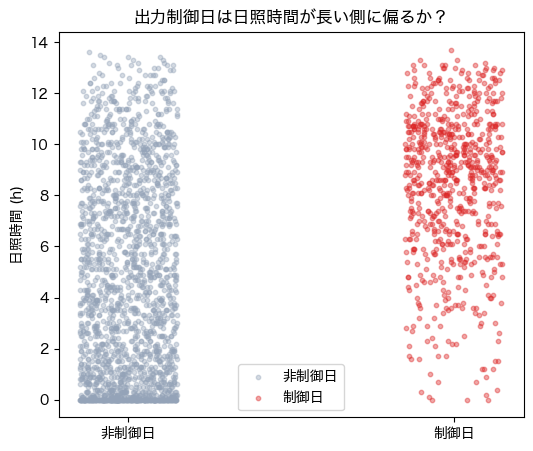

In [13]:
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(6, 5))
for label, sub, color in [("非制御日", df[df["is_curtailed"] == 0], "#94a3b8"),
                           ("制御日", df[df["is_curtailed"] == 1], "#dc2626")]:
    jitter = rng.uniform(-0.15, 0.15, len(sub))
    x = sub["is_curtailed"].astype(int) + jitter
    ax.scatter(x, sub["sunshine_h"], s=10, alpha=0.4, color=color, label=label)
ax.set_xticks([0, 1]); ax.set_xticklabels(["非制御日", "制御日"])
ax.set_ylabel("日照時間 (h)")
ax.set_title("出力制御日は日照時間が長い側に偏るか？")
ax.legend()
plt.show()


見た目では「制御日は上の方（日照時間が長い側）に集まっている」ように見えます。これを数値で確認するために **Cohen's d**（効果量）を計算します。

Cohen's d は「2つのグループの平均の差を、データの散らばり（標準偏差）で正規化した指標」です。ざっくりした目安として、0.2=小さい、0.5=中程度、0.8以上=大きい、とされています。


In [14]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std() ** 2 + (nb - 1) * b.std() ** 2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std


curtailed = df[df["is_curtailed"] == 1]["sunshine_h"]
not_curtailed = df[df["is_curtailed"] == 0]["sunshine_h"]
d = cohens_d(curtailed, not_curtailed)

print(f"制御日の日照時間平均: {curtailed.mean():.2f}h")
print(f"非制御日の日照時間平均: {not_curtailed.mean():.2f}h")
print(f"Cohen's d = {d:.2f}（大きい効果量）")


制御日の日照時間平均: 8.46h
非制御日の日照時間平均: 4.58h
Cohen's d = 1.07（大きい効果量）


**Cohen's d が大きい値になりました。** 制御日は非制御日よりも日照時間が明確に長く、最初の仮説「晴れた日に出力制御が多い」は裏付けられました。

ここまでは順調ですが——実はこの時点のデータには、**重大なバグ**が潜んでいました。次の章で、そのバグがどうやって見つかったかを見ていきます。


## 4. 【教訓】データの「正しさ」を疑う

このプロジェクトの元データ（九州電力送配電の出力制御実績報告書）には、実は**2段階の決定**が記録されています。

- **「前日指示」**: 前日の天気予報に基づく、事前の出力制御の指示
- **「速報」**: 当日の実況に基づく、最終的な見直し（指示の取り消しや追加）

最初のバージョンの抽出コードは、**「前日指示」列だけを読んでおり、「速報」による取り消しを無視していました**。つまり「前日は晴れ予報で制御を指示したが、当日は曇って実際には制御不要だった」というケースを、誤って「制御日」としてカウントしてしまっていたのです。

### どうやって見つかったか

これは統計的な検定や機械学習のモデルでは検出できない種類の誤り（データの意味の取り違え）でした。見つかったきっかけは、**ユーザーからの「この散布図、全天日射量が小さいところでも出力制御が多いのはおかしくないか？」という指摘**でした。実際にデータを掘り直すと、前日は晴れ予報だったが当日は曇ったために取り消されたケースが多数見つかりました。

### 修正の影響

| 指標 | 修正前 | 修正後 |
|---|---|---|
| 九州の制御日数 | 1,175日 | **715日**（-39%） |
| 沖縄の制御日数 | 160日 | **44日**（-72.5%） |
| 日照時間のCohen's d（九州） | 0.73 | **1.07** |
| ロジスティック回帰のAUC（後述） | 0.852 | **0.904** |

**ノイズ（実際には制御不要だった日）を取り除いたことで、信号がむしろ強くなりました。**このノートブックのデータは、すでに修正済みの正しいバージョンを使っています（`src/parse_kyushu.py` の `extract_sheet` 関数が、速報を優先するロジックになっています）。

### 教訓
1. **散布図・生データを実際に目で見る工程を省略しない**。相関係数やAUCだけ見ていたら気づけなかった。
2. **「もっともらしすぎる結果」は疑う**。
3. **指摘を受けて直したら、関連する全ての図・モデル・ドキュメントへの伝播を確認する**。

### 質問による変更履歴（全8件）

このプロジェクトは、上の#8だけでなく、**ユーザーからの指摘を受けるたびに分析が訂正され、精度が上がっていった**という経緯があります。もし質問が無ければ、間違った/粗いまま「結論」として残っていた箇所が複数ありました。

| # | ユーザーの指摘・質問 | 当初の状態（問題点） | 調査・対応 | 結果・インパクト |
|---|---|---|---|---|
| 1 | 「日照時間よりは、全天日射量の方が発電量との相関が良いが、日射量でも調べた？」 | 出力制御の判別力（二値）しか見ておらず、全天日射量を試していなかった | 全天日射量でもCohen's dを計算 | 出力制御の**判別**には日照時間の方が強いという逆の結果に。後に「発電量（連続量）」では全天日射量が強いことが判明し、**目的変数で最適指標が違う**という発見につながった（#5と対になる。7章で確認） |
| 2 | 「amgsdsの日照時間は快晴などのときに、予測が過少になる傾向があるため、気象庁の天気予報より精度が良いかはわからない。過去の出力制御時のデータで検証できるか？」 | 「AMGSDSの方が気象庁予報より正確」と断定していた（過去日付のAPI応答が実況＝解析値であり予報ではないことに気づかず検証） | 過去日付の問い合わせが実況を返すだけと判明し検証方法自体を訂正。`ml_forecast`の既存の実測検証（予報vintageデータ）を調べ直した | **「AMGSDSの方が正確」は誤りと判明**。快晴日に-5h前後の系統的な過少評価があり、優劣はつけられないと訂正 |
| 3 | 「ml-forcastにある沖縄の日照時間の予報がある期間で...出力制御関連の検証はできるか」 | （検証を試みる前） | AMGSDS予報vintageアーカイブ（2026年5月〜）と沖縄の出力制御データ（〜2026年3月）の期間を確認 | **重複期間が無く検証不可能**と判明。無理に結論を出さず「今はできない」と明記する判断に |
| 4 | 「出力制御日は土日に多いというのは、季節による変動はないのか？」 | 「土日の割合37.4%」を季節を区別せず一つの数字として結論づけていた | 月別に出力制御日数・土日比率を集計 | **季節で全く逆の2パターンが混在**（春=頻発・曜日差小、夏〜初秋=希少・土日に極端に偏る）と判明。ロジスティック回帰に月を特徴量として追加する着想につながった（#6、6章で確認） |
| 5 | （上記#4の指摘を受けた追加確認）「reportの図も季節別の分析に対応させて変更した？まとめも。」 | 季節変動を文章では記録したが、既存の図（曜日別割合）・ロジスティック回帰モデル・まとめ表には未反映のまま放置していた | 月をダミー変数としてロジスティック回帰に実際に追加して再学習 | AUCが0.669→0.852（後に訂正でさらに変化）に大幅改善。**季節が日照時間・曜日より強力な予測因子**と判明。「書いたら即モデルに反映する」ことの重要性を再確認 |
| 6 | 「6.実際の発電量との精度比較は風力も入れているが日射量とは関係ない。太陽光のみのデータはないのか？」 | 「エリア風力・太陽光発電量」の合計を使い、太陽光単独の相関として報告していた | 太陽光単独の実績データ（旧形式+新形式を接続）を新たに取得 | 相関がさらに強まり（全天日射量r=0.819→0.835等）、結論の方向は変わらなかったが**データの正確性が向上** |
| 7 | 「太陽光発電量は、電力会社が太陽光発電の電力を買った量？」 | 「発電量」という言葉を無頓着に使っていた（パネルの発電能力と誤解されうる） | データの出典（系統情報公表の考え方）を確認し定義を明記 | 「系統に実際に流れ込んだ出力」である旨をドキュメント・コードに明記。**用語の誤解を防ぐドキュメント化**（7章の注記を参照） |
| 8 | 「⑧図の相関図がよくわからない。全天日射量が小さいところは、太陽光発電量も少ないはずで、その領域では出力制御をかけないのでは？」 | **最重要の発見**。「制御日」の判定が「前日指示（予報ベース）」列だけを読んでおり、当日の「速報（実況ベースの見直し）」を無視していた | Excel/PDFの構造を再調査し、前日は晴れ予報で指示したが当日は曇って実際には不要だった、という取り消しケースが多数存在することを実データで確認。パーサーを「速報があれば速報を優先」するロジックに修正 | **制御日数が九州1175日→715日（-39%）、沖縄160日→44日（-72.5%）に激減**。以降の全ての分析を再計算し、信号は軒並み大幅に強くなった |

全経緯のさらに詳しい記録（訂正前後の図の比較つき）は [CORRECTIONS_LOG.md](CORRECTIONS_LOG.md) を参照してください。


## 5. 季節性の発見

もう一つの発見です。「出力制御は休日に多い」という傾向がありますが、これを季節別に分解すると、実は**季節によって全く違う2つのパターン**が混ざっていることが分かります。


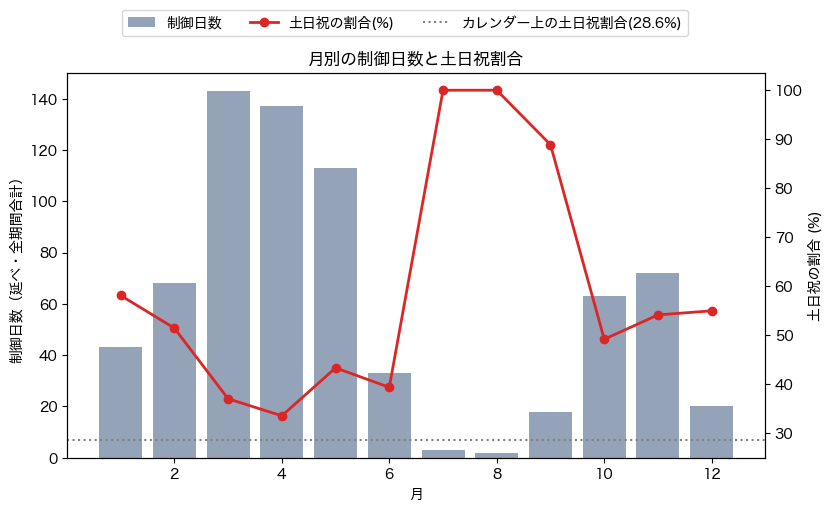

In [15]:
df["month"] = df["date"].dt.month
monthly = df[df["is_curtailed"] == 1].groupby("month").agg(
    n=("is_curtailed", "size"),
    weekend_ratio=("is_weekend_or_holiday", "mean"),
)
monthly["weekend_ratio"] *= 100

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(monthly.index, monthly["n"], color="#94a3b8", label="制御日数")
ax1.set_xlabel("月"); ax1.set_ylabel("制御日数（延べ・全期間合計）")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["weekend_ratio"], color="#dc2626", marker="o", lw=2, label="土日祝の割合(%)")
ax2.axhline(28.6, color="gray", ls=":", label="カレンダー上の土日祝割合(28.6%)")
ax2.set_ylabel("土日祝の割合 (%)")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3)
ax1.set_title("月別の制御日数と土日祝割合")
plt.show()


**春（3〜5月）は制御が頻発し、土日祝の割合はカレンダー通りに近い**一方、**夏〜初秋（7〜9月）は制御が少なく、起きるときはほぼ土日祝に集中**しています。

これは、春は需要そのものが少なく平日でも供給過多になりやすいため曜日差が出にくく、夏〜初秋は冷房需要で平日需要が高く保たれるため、供給過多が土日に限られる、と解釈できます。

→ つまり「曜日」だけでなく「季節（月）」も重要な特徴量だと分かりました。次の章でモデルに組み込みます。


## 6. ロジスティック回帰で予測する

ここまでの発見（晴天・曜日・季節）を使って、「その日に出力制御があるかどうか」を予測するロジスティック回帰モデルを作ります。

**評価の仕方に注意**: ランダムに学習用・評価用データを分けると、同じ季節のデータが両方に混ざってしまい、楽観的な（甘い）評価になります。ここでは**時系列で前70%を学習、残り30%を評価**に使います。


In [16]:
def evaluate(data, features, label, train_ratio=0.7):
    n_train = int(len(data) * train_ratio)
    train, test = data.iloc[:n_train], data.iloc[n_train:]

    model = LogisticRegression(max_iter=1000)
    model.fit(train[features], train["is_curtailed"])
    proba = model.predict_proba(test[features])[:, 1]
    pred = (proba >= 0.5).astype(int)

    auc = roc_auc_score(test["is_curtailed"], proba)
    precision = precision_score(test["is_curtailed"], pred, zero_division=0)
    recall = recall_score(test["is_curtailed"], pred, zero_division=0)
    return {"特徴量": label, "AUC": round(auc, 3), "適合率": round(precision, 3), "再現率": round(recall, 3)}


df["years_since_start"] = (df["date"] - df["date"].min()).dt.days / 365.25
month_dummies = pd.get_dummies(df["month"], prefix="month", drop_first=True)
df = pd.concat([df, month_dummies], axis=1)
month_cols = list(month_dummies.columns)

results = []
results.append(evaluate(df, ["is_weekend_or_holiday"], "曜日のみ"))
results.append(evaluate(df, ["sunshine_h"], "日照時間のみ"))
results.append(evaluate(df, ["sunshine_h", "is_weekend_or_holiday"], "日照時間＋曜日"))
results.append(evaluate(df, ["sunshine_h", "is_weekend_or_holiday", "years_since_start"],
                         "日照時間＋曜日＋トレンド"))
results.append(evaluate(df, month_cols + ["sunshine_h", "is_weekend_or_holiday", "years_since_start"],
                         "月＋日照＋曜日＋トレンド（フル）"))

pd.DataFrame(results)


,特徴量,AUC,適合率,再現率
0,曜日のみ,0.571,0.000,0.000
1,日照時間のみ,0.756,0.470,0.162
2,日照時間＋曜日,0.777,0.609,0.241
3,日照時間＋曜日＋トレンド,0.777,0.591,0.515
4,月＋日照＋曜日＋トレンド（フル）,0.904,0.774,0.777


**読み方**:
- **AUC（0.5〜1.0）**: 「ランダムな制御日・非制御日を1日ずつ見せたとき、モデルが制御日により高い確率を付けられる割合」。0.5はランダムと同じ、1.0は完璧。0.7台は「中〜高程度」、0.9を超えると「高い」。
- **適合率**: モデルが「制御あり」と予測した日のうち、実際に制御があった割合（誤報の少なさ）。
- **再現率**: 実際に制御があった日のうち、モデルが正しく「制御あり」と予測できた割合（見逃しの少なさ）。

「曜日のみ」「日照時間のみ」よりも「両方使う」方がAUCが上がっており、2つが**相補的な情報**を持っていることが分かります。さらに**「月（季節）」を加えると、AUCが大きく改善**しました。季節は日照時間・曜日のどちらにも匹敵する強力な予測因子だったのです（5章の発見の通り）。


## 7. 実際の発電量との関係：頭打ち効果

ここまでは「出力制御があったか・なかったか」という**二値**を予測してきました。もう一つの確認方法として、実際の**発電量（連続量、MWh）**と気象データの関係を見てみます。

> **「発電量」の意味に注意**（これも実はユーザーからの指摘で明記した点です、上の変更履歴#7）:ここでの「太陽光実績」は発電パネルが作った電力の総量ではなく、**系統（電力網）に実際に流れ込んだ太陽光の出力**（九州電力送配電の公表データ）です。出力制御で発電を止めるとこの値自体が下がります。


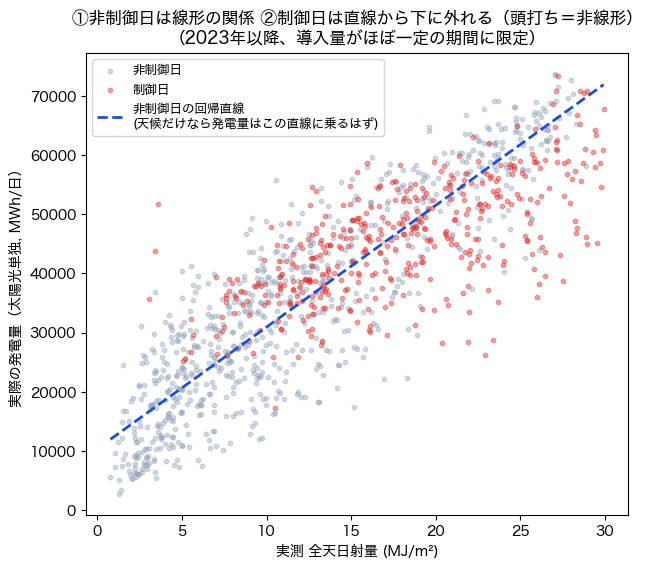

全天日射量と発電量の相関 r = 0.846
日照時間と発電量の相関　  r = 0.821


In [17]:
gen = pd.read_csv(f"{DATA_DIR}/kyushu_generation_merged.csv", parse_dates=["date"])
# 太陽光の導入量が年々増えているため、頭打ち効果を公平に見るには導入量がほぼ一定の
# 直近期間に限定する（全期間だと「天気」ではなく「導入量の違う年の混在」になってしまう）
gen_recent = gen[gen["date"] >= "2023-01-01"]
non_c = gen_recent[gen_recent["is_curtailed"] == 0]
curt = gen_recent[gen_recent["is_curtailed"] == 1]

# 非制御日だけで1次式を回帰（「晴れれば発電量も素直に伸びる」という線形の基準線）
slope, intercept = np.polyfit(non_c["solar_mj"], non_c["solar_mwh"], 1)
x_line = np.array([gen_recent["solar_mj"].min(), gen_recent["solar_mj"].max()])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(non_c["solar_mj"], non_c["solar_mwh"], s=10, alpha=0.4, color="#94a3b8", label="非制御日")
ax.scatter(curt["solar_mj"], curt["solar_mwh"], s=10, alpha=0.4, color="#dc2626", label="制御日")
ax.plot(x_line, slope * x_line + intercept, color="#1d4ed8", lw=2, ls="--",
        label="非制御日の回帰直線\n(天候だけなら発電量はこの直線に乗るはず)")
ax.set_xlabel("実測 全天日射量 (MJ/m²)")
ax.set_ylabel("実際の発電量（太陽光単独, MWh/日）")
ax.set_title("①非制御日は線形の関係 ②制御日は直線から下に外れる（頭打ち＝非線形）\n（2023年以降、導入量がほぼ一定の期間に限定）")
ax.legend(fontsize=9)
plt.show()

r_all = gen_recent["solar_mwh"].corr(gen_recent["solar_mj"])
r_sunshine_all = gen_recent["solar_mwh"].corr(gen_recent["sunshine_h"])
print(f"全天日射量と発電量の相関 r = {r_all:.3f}")
print(f"日照時間と発電量の相関　  r = {r_sunshine_all:.3f}")


**非制御日（灰）は回帰直線にほぼ乗る線形の関係ですが、制御日（赤）はこの直線から下に外れています。**これが出力制御の「頭打ち効果」です——同じ日射量でも、制御された日は発電量が伸びていません。

さらに面白いのは、**発電量との相関は全天日射量の方が日照時間より高い**という結果です（3章の「出力制御の有無」という二値の判別では逆に日照時間の方が強かったことを思い出してください）。

→ **目的変数（何を予測したいか）によって、最適な気象指標は変わる**という教訓です。これも変更履歴#1・#5のきっかけになった発見でした。


## 8. トレンド項を「経過年数」から実際の導入容量に置き換える

上のモデルでは `years_since_start`（分析開始日からの経過年数）を「太陽光の導入量が年々増えている」ことの近似として使っています。これは粗い近似ですが、**資源エネルギー庁のFIT/FIPポータル**が公表している、実際の太陽光導入容量（設備容量）のデータに置き換えると、精度は上がるでしょうか？


In [18]:
cap = pd.read_csv(f"{DATA_DIR}/kyushu_pv_capacity_quarterly.csv", parse_dates=["date"])
cap = cap.set_index("date")["capacity_kw"].sort_index()
daily_index = pd.date_range(cap.index.min(), cap.index.max(), freq="D")
cap_daily = cap.reindex(daily_index).interpolate("linear")  # 四半期点を日次に線形補間

df["capacity_million_kw"] = df["date"].map(cap_daily) / 1e6

print(f"九州本土7県の太陽光導入容量: {cap.iloc[0]/1e6:.2f}百万kW（{cap.index[0].date()}）"
      f" → {cap.iloc[-1]/1e6:.2f}百万kW（{cap.index[-1].date()}）")

results_trend = [
    evaluate(df, month_cols + ["sunshine_h", "is_weekend_or_holiday", "years_since_start"],
             "トレンド＝経過年数"),
    evaluate(df, month_cols + ["sunshine_h", "is_weekend_or_holiday", "capacity_million_kw"],
             "トレンド＝実際の導入容量"),
]
pd.DataFrame(results_trend)


九州本土7県の太陽光導入容量: 7.38百万kW（2017-06-30） → 12.70百万kW（2026-03-31）


,特徴量,AUC,適合率,再現率
0,トレンド＝経過年数,0.904,0.774,0.777
1,トレンド＝実際の導入容量,0.905,0.841,0.653


**AUCはほとんど変わりません。** 「経過年数」という粗い近似でも、判別力そのものは実際の導入容量とほぼ同等でした。一方で、しきい値0.5での適合率・再現率のバランスは変わります（実際の導入容量を使うとモデルがより保守的になります）。

→ 教訓: 「もっと正確なデータを使えば必ず精度が上がる」とは限らない。この場合、トレンド項の「形」よりも「トレンド項があるかどうか」自体が効いていました。


## 9. 単一点より九州全体の面で見る

これまでの日照時間は、**福岡1点だけ**で九州全体を代表させていました。しかし出力制御は九州本土全域の電力系統で起きる現象です。1点より面（複数地点の平均）で見た方が、実際の晴天状況を正しく捉えられるのではないか？

2つの方法を比較します:
- **AMeDAS 7県平均**: 福岡・佐賀・長崎・熊本・大分・宮崎・鹿児島の気象官署7点の単純平均
- **AMGSDSメッシュ面平均**: 農研機構の気象メッシュデータの九州本土の陸地セル（約37,700点）の面平均


,特徴量,AUC,適合率,再現率
0,福岡単一点,0.904,0.774,0.777
1,AMeDAS九州7県平均,0.925,0.780,0.794
2,AMGSDS九州メッシュ面平均,0.924,0.772,0.801


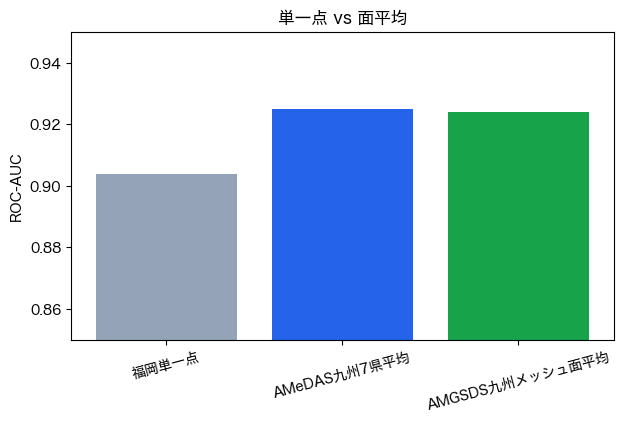

In [19]:
kyushu_mean = pd.read_csv(f"{DATA_DIR}/sunshine_kyushu_mainland_mean.csv", parse_dates=["date"])
amgsds_mesh = pd.read_csv(f"{DATA_DIR}/sunshine_amgsds_kyushu_mesh_mean.csv", parse_dates=["date"])

df2 = df.merge(kyushu_mean[["date", "sunshine_h_kyushu_mean"]], on="date", how="left")
df2 = df2.merge(amgsds_mesh[["date", "sunshine_h_amgsds_mesh_mean"]], on="date", how="left")
df2 = df2.dropna(subset=["sunshine_h_kyushu_mean", "sunshine_h_amgsds_mesh_mean"]).reset_index(drop=True)

results_area = [
    evaluate(df2, month_cols + ["sunshine_h", "is_weekend_or_holiday", "years_since_start"],
             "福岡単一点"),
    evaluate(df2, month_cols + ["sunshine_h_kyushu_mean", "is_weekend_or_holiday", "years_since_start"],
             "AMeDAS九州7県平均"),
    evaluate(df2, month_cols + ["sunshine_h_amgsds_mesh_mean", "is_weekend_or_holiday", "years_since_start"],
             "AMGSDS九州メッシュ面平均"),
]
result_df = pd.DataFrame(results_area)
display(result_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(result_df["特徴量"], result_df["AUC"], color=["#94a3b8", "#2563eb", "#16a34a"])
ax.set_ylim(0.85, 0.95)
ax.set_ylabel("ROC-AUC")
ax.set_title("単一点 vs 面平均")
plt.xticks(rotation=15)
plt.show()


**単一点より面で見た方が明確に精度が上がりました**（AUC 0.904 → 0.924〜0.925）。これは本プロジェクト最高のAUCです。さらに、AMeDAS7県平均とAMGSDSメッシュ面平均はほぼ同じ精度だったため、**わざわざ高解像度メッシュを使わなくても、既存の気象官署7点の単純平均で十分**という実務上有用な結論も得られました。


## 10. 翌日の判定に落とし込む（GenAI角）

最後に、このモデルを使って「明日は出力制御が起きそうか」を実際に判定してみます。本番のパイプライン（`src/forecast_narrative.py`）は気象庁の天気予報とAMGSDSの数値予報を使って自動で実行しますが、ここでは考え方を再現するために、架空の入力（晴れ予報・土曜日・日照時間6時間と仮定）で試してみます。


In [20]:
# 最良モデル（月＋日照〔九州メッシュ面平均〕＋曜日＋トレンド）を学習
best_features = month_cols + ["sunshine_h_amgsds_mesh_mean", "is_weekend_or_holiday", "years_since_start"]
best_model = LogisticRegression(max_iter=1000)
best_model.fit(df2[best_features], df2["is_curtailed"])


def proba_to_label(proba):
    if proba < 0.30:
        return "低い"
    elif proba < 0.60:
        return "中程度"
    return "高い"


# 架空の例: 来月1日・土曜・晴れ予報で日照時間6.0hと仮定
example_date = pd.Timestamp(df2["date"].max()) + pd.Timedelta(days=1)
x_example = {f"month_{example_date.month}": 1} if f"month_{example_date.month}" in month_cols else {}
x_example.update({
    "sunshine_h_amgsds_mesh_mean": 6.0,
    "is_weekend_or_holiday": 1,
    "years_since_start": (example_date - df2["date"].min()).days / 365.25,
})
x_row = pd.DataFrame([{c: x_example.get(c, 0) for c in best_features}])
proba = float(best_model.predict_proba(x_row)[0, 1])

print(f"{example_date.date()}（仮に晴れ予報・休日・日照時間6.0hとした場合）")
print(f"  出力制御の予測確率: {proba*100:.0f}%")
print(f"  判定: 可能性「{proba_to_label(proba)}」")


2026-04-01（仮に晴れ予報・休日・日照時間6.0hとした場合）
  出力制御の予測確率: 98%
  判定: 可能性「高い」


このように、生の確率だけでなく「低い／中程度／高い」という明確な判定ラベルに変換して表示することで、専門家でなくても一目で状況を把握できるようにしています（この工夫も、「平文の説明だけでは分かりにくい」というユーザーからの指摘がきっかけで追加されました）。

本番のパイプライン（気象庁の実際の予報取得→AMGSDS数値予報→Claudeによる補足説明の生成まで含む）を動かすには、農研機構AMGSDSの認証とAnthropicのAPIキーが必要です。`src/forecast_narrative.py --dry-run` でAPIキーなしでも判定部分だけは確認できます。


## 11. まとめ・教訓

| 問い | 結果 |
|---|---|
| 出力制御は天気・曜日で説明できるか | 単独では中程度（AUC 0.78前後）。季節を加えると大きく改善（AUC 0.90） |
| もっと正確なトレンド項を使えば良くなるか | 必ずしもそうではない（経過年数の近似でも十分だった） |
| 単一点より面で見た方が良いか | **Yes**。本プロジェクト最高のAUC（0.92台）を記録 |
| 高解像度メッシュは必須か | **No**。気象官署7点の単純平均で同等の精度 |

### このノートブックから持ち帰ってほしいこと

1. **散布図・生データを実際に目で見る工程を省略しない**。指標だけでは見えない誤りがある。
2. **「もっともらしすぎる結果」は疑う**。綺麗すぎる結果はたいてい見ているものが違う。
3. **指摘を受けて直したら、関連するすべての図・モデル・ドキュメントへの伝播を確認する**。
4. **「もっと精密なデータ」が必ずしも「もっと良いモデル」になるとは限らない**（8章）。
5. 一方で、**データの集め方（単一点か面か）はモデルの質に直結する**（9章）。

このノートブックの元になった、実際の分析・訂正の全記録は以下を参照してください:
- [README.md](README.md) — 検証の結論と詳細
- [REPORT.md](REPORT.md) — スライド化を見据えた図表付きサマリー
- [CORRECTIONS_LOG.md](CORRECTIONS_LOG.md) — ユーザーの指摘が分析を正していった8件の記録（**一番の読みどころ**）
